## CIFAR-100 - Representations from ResNet-18

In [1]:
from fenec import FeNeC
from feloc import FeLoC
from kmeans import KMeans
import utils
import metrics

f:\COnda\envs\fecam\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = utils.get_device()

Device used: cpu


### Sample run

Using FeNeC:

In [ ]:
# Define the Classifier metric and the KMeans metric
metric = metrics.MahalanobisMetric(shrinkage=2, gamma_1=0.9, gamma_2=0.9, normalization=True)
metric_kmeans = metrics.EuclideanMetric()

# Initialize KMeans and FeNeC
kmeans = KMeans(n_clusters=1, metric=metric_kmeans)
clf = FeNeC(n_neighbors=1,
            metric=metric,
            data_normalization=False,
            tukey_lambda=0.4,
            kmeans=kmeans,
            covariance_per_centroid=False,
            device=device)

# Run the classifier on the dataset
_ = utils.train(clf=clf, folder_name='./data/dataset5', n_tasks=6, only_last=False, verbose=1)

|   Task |   Class num | Precision   | Recall   |   FScore |   Accuracy | % of all Answers   |
|-------:|------------:|:------------|:---------|---------:|-----------:|:-------------------|
|      0 |          50 | 88.12%      | 87.12%   |     0.87 |       0.87 | 100.00%            |
task 0: (time: 5.3754s)
FeCAM accuracy: 86.9600; My accuracy: 87.1200
|   Task |   Class num | Precision   | Recall   |   FScore |   Accuracy | % of all Answers   |
|-------:|------------:|:------------|:---------|---------:|-----------:|:-------------------|
|      0 |          50 | 90.06%      | 82.96%   |     0.86 |       0.83 | 77.07%             |
|      1 |          10 | 64.01%      | 79.80%   |     0.69 |       0.8  | 22.93%             |
task 1: (time: 5.6007s)
FeCAM accuracy: 82.2333; My accuracy: 82.4333


KeyboardInterrupt: 

Using FeLoC:

In [15]:
# Define the Classifier metric and the KMeans metric
metric = metrics.MahalanobisMetric(shrinkage=2, gamma_1=1.1, gamma_2=1.9, normalization=True)
metric_kmeans = metrics.EuclideanMetric()

# Initialize KMeans and FeLoC
kmeans = KMeans(n_clusters=45, metric=metric_kmeans)
clf = FeLoC(metric=metric,
            kmeans=kmeans,
            data_normalization=False,
            device=device,
            tukey_lambda=0.4,
            batch_size=8,
            optimizer="SGD",
            n_points=2,
            mode=0,
            num_epochs=200,
            lr=0.003,
            early_stop_patience=10,
            reg_type=None,
            reg_lambda=None,
            normalization_type=None,
            tanh_x=None,
            centroids_new_old_ratio=None,
            train_only_on_first_task=True,
            dataloader_batch_size=64)

# Run the classifier on the dataset
_ = utils.train(clf=clf, folder_name='../data/dataset2', n_tasks=6, only_last=False, verbose=1)

Dataloader created
Validation Accuracy after Epoch [1/200]: 100.00%, Loss = 2.0065,
Validation Accuracy after Epoch [11/200]: 100.00%, Loss = 0.2018,
Validation Accuracy after Epoch [21/200]: 100.00%, Loss = 0.0983,
Validation Accuracy after Epoch [31/200]: 100.00%, Loss = 0.0654,
Validation Accuracy after Epoch [41/200]: 100.00%, Loss = 0.0494,
Validation Accuracy after Epoch [51/200]: 100.00%, Loss = 0.0399,
Validation Accuracy after Epoch [61/200]: 100.00%, Loss = 0.0336,
Validation Accuracy after Epoch [71/200]: 100.00%, Loss = 0.0291,
Validation Accuracy after Epoch [81/200]: 100.00%, Loss = 0.0257,
Validation Accuracy after Epoch [91/200]: 100.00%, Loss = 0.0231,
Validation Accuracy after Epoch [101/200]: 100.00%, Loss = 0.0210,
Validation Accuracy after Epoch [111/200]: 100.00%, Loss = 0.0192,
Validation Accuracy after Epoch [121/200]: 100.00%, Loss = 0.0178,
Validation Accuracy after Epoch [131/200]: 100.00%, Loss = 0.0166,
Validation Accuracy after Epoch [141/200]: 100.00%, Lo

## Grid search results - plot hyperparameters

In [3]:
study_name = "resnett"

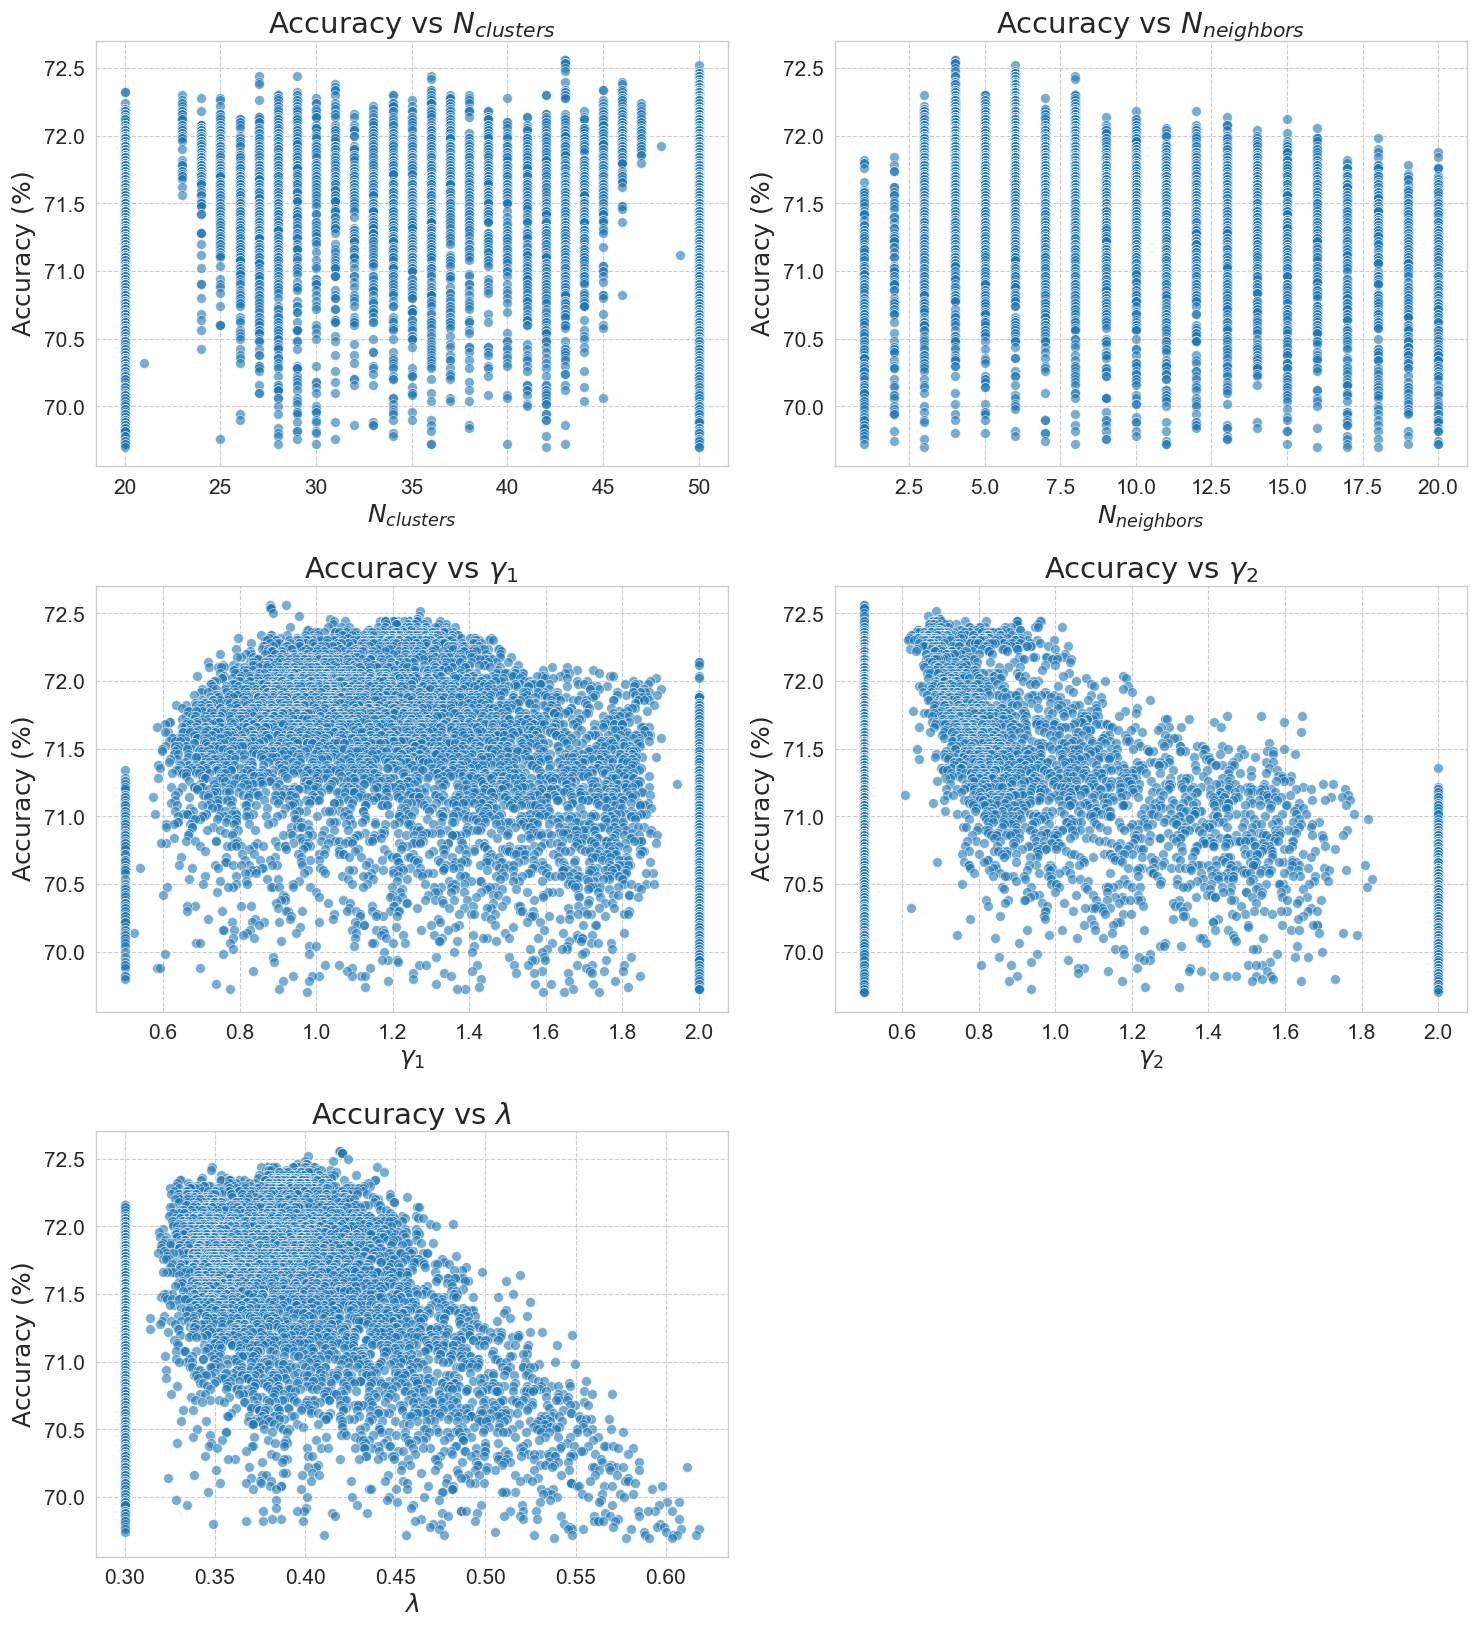

In [23]:
utils.plot_params_accuracy(study_name=study_name, path='./results/final/', ylim=True, only_later=None, columns=2)

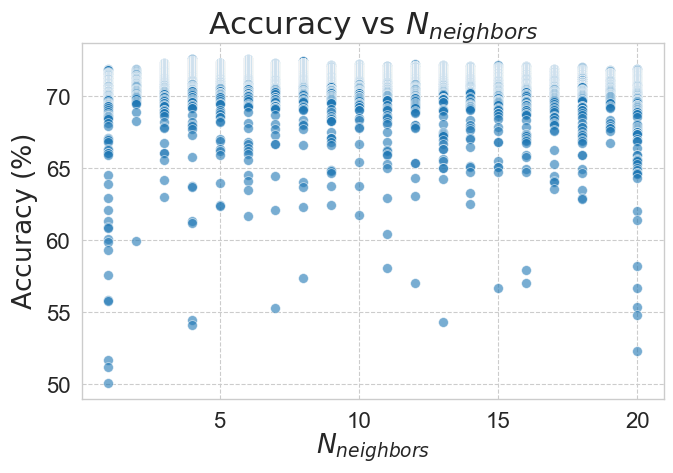

In [4]:
# Load data and extract names
df = utils.load_from_csv(study_name=study_name, path='./results/final/')

name = "FeNeC_ResNet_CIFAR"
param_name = "n_neighbors"

accuracies = df['value'].values
param_vals = df[f'params_{param_name}'].values
path_to_pdf = f"plots/{name}_acc_vs_{param_name}.pdf"
title = utils.format_param_accuracy_title(param_name)

utils.plot_param_accuracy(param_name=param_name, param_vals=param_vals, accuracies=accuracies, ylim=True, 
                               ylim_set=44, xlim_set=None, only_later=0, fig_size=(7, 5), font_scale=1.6,
                               title_pad=7, label_pad=0, title=title, path_to_pdf=path_to_pdf)

Colorful plots

f:\github\continual-learning-fecam\utils.py:317: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


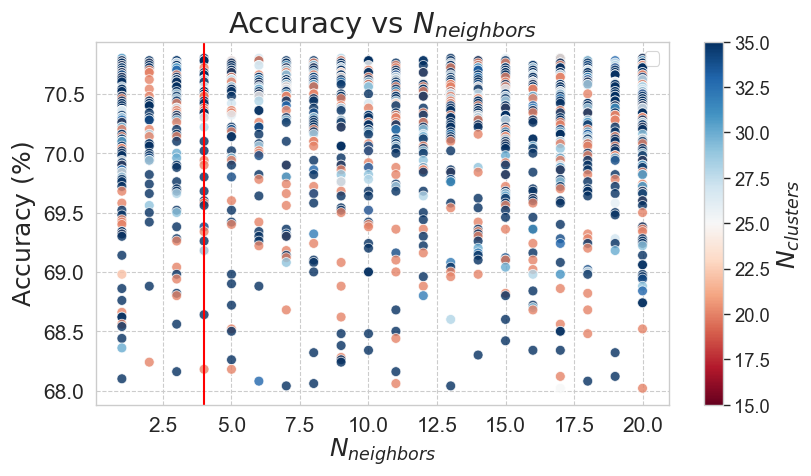

In [57]:
name = "FeNeC_ResNet_CIFAR"
x_name, y_name, hue_name = "n_neighbors", "accuracy", "n_clusters"

df = utils.load_from_csv(study_name=study_name, path='./results/final/')
path_to_pdf = f"plots/{name}_{y_name}_vs_{x_name}.pdf"

utils.plot_acc_param_hue(df, x_name, y_name, hue_name, 
                         ylim=True, ylim_set=68, xlim_set=None, only_later=0.2,
                         s_plot=50, alpha_plot=0.8, line_style=1,
                         palette='RdBu', show_bar=True, bar_lim=(15, 35),
                         title_pad=7, label_pad=0, font_scale=1.5,  
                         fig_size=(7, 5), path_to_pdf=path_to_pdf,best_trial_number=6180) 

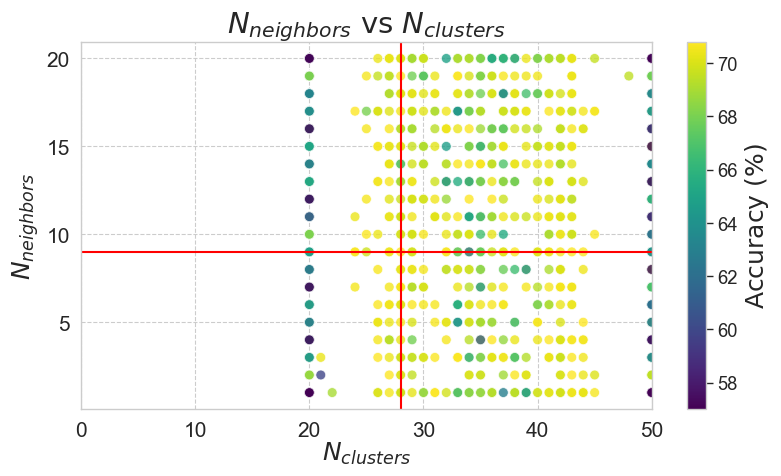

In [ ]:
name = "FeNeC_ResNet_CIFAR"
x_name, y_name, hue_name = "n_clusters", "n_neighbors", "accuracy"

df = utils.load_from_csv(study_name=study_name, path='./results/final/')
path_to_pdf = f"plots/{name}_{y_name}_vs_{x_name}.pdf"

utils.plot_acc_param_hue(df, x_name, y_name, hue_name, 
                         ylim=False, ylim_set=(0,40), xlim_set=(0,50), only_later=0.1,
                         s_plot=50, alpha_plot=0.8, line_style=2,
                         palette='viridis', show_bar=True, bar_lim=(57, None),
                         title_pad=7, label_pad=0, font_scale=1.5,
                         fig_size=(7, 5), path_to_pdf=path_to_pdf) # mako, rocket_r, flare, crest_r